# NCCT Multi-Stage Classification **V2** — Backbone Ablation + Fixed Split

Pipeline klasifikasi **bertingkat** pada citra CT Non-Contrast (NCCT) pasien stroke — **V2**, peningkatan dari V1:

```
                    ┌────────────────────────────────────────────┐
  Citra NCCT  ──►   │  STAGE 1 : Apakah pasien mengalami LVO?    │
                    └────────────────────────────────────────────┘
                              │ Ya                        │ Tidak
                              ▼                           ▼
              ┌───────────────────────────────┐      Non-LVO
              │ STAGE 2 : Laterality          │     (selesai)
              │   Left / Right                │
              ├───────────────────────────────┤
              │ STAGE 3 : Etiologi            │
              │   Cardioembolic / Non-Cardio  │
              └───────────────────────────────┘
```

## Apa yang Berubah dari V1

| Aspek | V1 | V2 |
|-------|----|----|
| **Split data** | on-the-fly per stage (tiap run beda) | **Fixed split** dari `NCCT_Fixed_Dataset_Split.ipynb` → reproducible, konsisten antar stage |
| **Backbone** | tunggal `resnet18` | **Ablation 4 backbone** (resnet18, resnet50, efficientnet_b0, convnext_tiny) |
| **Training** | 1 epoch (demo) | Epoch cukup + linear warmup + cosine annealing + **AMP** + gradient clipping + multi-seed |
| **Evaluasi** | hanya level citra | **Level citra + level PASIEN** (mean prob per pasien) — relevan utk keputusan klinis |
| **Hasil** | model terbaik per stage | Model terbaik per stage + **tabel ablation otomatis** (JSON/CSV/Markdown) |

**Sumber data (FIXED SPLIT):** zip dari Google Drive (dibuat oleh `NCCT_Fixed_Dataset_Split.ipynb`):
- `metadata/{stage1_lvo,stage2_laterality,stage3_etiology}/{train,val,test}.csv`
- Folder citra `train/`, `val/`, `test/` (struktur asli dipertahankan)

**Stage:**
- **Stage 1** — LVO vs Non-LVO (semua pasien)
- **Stage 2** — Left vs Right (hanya LVO, ada label laterality)
- **Stage 3** — Cardioembolic vs Non-Cardioembolic (hanya LVO, ada label etiologi)

### 1. Install & Import Library

In [21]:
!pip install -q gdown timm openpyxl seaborn scikit-learn

In [22]:
import os, re, glob, zipfile, random, time, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from IPython.display import display

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import timm

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, roc_auc_score, classification_report)

warnings.filterwarnings('ignore')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)


def set_seed(seed):
    """Set semua random seed utk reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

Device: cuda


### 2. Konfigurasi

Ubah `MODE` menjadi `'local'` untuk uji cepat dengan sample lokal, atau `'colab'` untuk dataset penuh dari Google Drive.

> **PENTING:** di V2 dataset **tidak displit ulang**. Zip berisi *fixed split* yang sudah dibuat sekali oleh
> `NCCT_Fixed_Dataset_Split.ipynb` (seed tetap 42). Folder sample lokal memakai CSV split penuh, sehingga
> baris yang citranya tidak ada di folder lokal otomatis disaring saat loading.

In [23]:
# ============================================================
#  KONFIGURASI V2
# ============================================================
MODE = 'colab'      # 'colab' → download zip FIXED SPLIT dari Google Drive
                    # 'local' → pakai folder sample lokal NCCT_fixed_split/

GDRIVE_FILE_ID = '1PAMWLa6TAh_yFW5RY4FQxDqjIoytqgcb'   # ID zip FIXED SPLIT di Google Drive
SPLIT_ZIP      = 'NCCT_fixed_split.zip'                 # nama zip hasil download
SPLIT_DIR      = 'NCCT_fixed_split'                     # folder hasil ekstrak / folder sample lokal

IMG_SIZE   = 224
BATCH_SIZE = 32

# ===== ABLATION BACKBONE (A1) =====
BACKBONES  = ['resnet18', 'resnet50', 'efficientnet_b0', 'convnext_tiny']
PRETRAINED = True              # pakai bobot ImageNet

# ===== CONFIG TRAINING PROPER (B3) =====
EPOCHS        = 1             
LR            = 1e-4
PATIENCE      = 5              # early stopping (val F1)
WARMUP_EPOCHS = 1              # linear warmup sebelum cosine annealing
GRAD_CLIP     = 1.0            # gradient clipping (max norm)
WEIGHT_DECAY  = 1e-4
AMP           = True           # mixed precision (lebih cepat & hemat VRAM di Colab)

# ===== MULTI-SEED (reproducibility) =====
SEEDS = [42]                   # tambah seed utk mean±std, mis. [42, 43, 44]

# ===== EVALUASI LEVEL PASIEN (C1) =====
PATIENT_LEVEL = True           # agregasi prob per-pasien → metrik level pasien

OUTPUT_DIR = 'outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print('Mode:', MODE, '| Device:', device)
print('Backbones:', BACKBONES)
print('Epochs:', EPOCHS, '| AMP:', AMP, '| Seeds:', SEEDS, '| Patient-level:', PATIENT_LEVEL)

Mode: colab | Device: cuda
Backbones: ['resnet18', 'resnet50', 'efficientnet_b0', 'convnext_tiny']
Epochs: 1 | AMP: True | Seeds: [42] | Patient-level: True


### 3. Download Dataset Fixed Split dari Google Drive

Download zip **fixed split** (bukan dataset mentah) → hasil langsung siap dipakai, **tanpa split ulang**.

In [24]:
if MODE == 'colab':
    !gdown {GDRIVE_FILE_ID}
    zips = [z for z in glob.glob('*.zip') if 'fixed' in z.lower()] or glob.glob('*.zip')
    print('Zip hasil download:', zips)
    if not zips:
        raise RuntimeError('Tidak ada zip. Periksa GDRIVE_FILE_ID.')
    zip_src = SPLIT_ZIP if os.path.exists(SPLIT_ZIP) else zips[0]
    !unzip -q -o {zip_src}
    print('Isi SPLIT_DIR:', sorted(os.listdir(SPLIT_DIR)))
else:
    assert os.path.isdir(SPLIT_DIR), f'Folder {SPLIT_DIR} tidak ditemukan (mode local).'
    print('Mode local → pakai folder sample:', SPLIT_DIR)
    print('Isi:', sorted(os.listdir(SPLIT_DIR)))

Downloading...
From (original): https://drive.google.com/uc?id=1PAMWLa6TAh_yFW5RY4FQxDqjIoytqgcb
From (redirected): https://drive.google.com/uc?id=1PAMWLa6TAh_yFW5RY4FQxDqjIoytqgcb&confirm=t&uuid=b877cc3c-3ce7-4183-89fd-94038b35b14a
To: /content/NCCT_fixed_split.zip
100% 334M/334M [00:02<00:00, 139MB/s] 
Zip hasil download: ['NCCT_fixed_split.zip']
Isi SPLIT_DIR: ['metadata', 'split_summary.json', 'test', 'train', 'val']


### 4. Load Fixed Split

CSV metadata per stage + per set dimuat, lalu `image_path` relatif diubah menjadi absolut terhadap `SPLIT_DIR`.

- `filter_missing=True` → baris yang citranya tidak ada dibuang (agar mode `local` dengan sample tetap jalan).

In [25]:
STAGES = ['stage1_lvo', 'stage2_laterality', 'stage3_etiology']
SPLITS = ('train', 'val', 'test')


def load_fixed_split(split_root=SPLIT_DIR, filter_missing=True):
    """Muat CSV split FIXED dari folder hasil split.

    - `image_path` relatif (mis. `train/LVO/p1_.../03.jpg`) → absolut thd split_root.
    - `filter_missing=True` → buang baris yg citranya tidak ada (utk sample lokal).
    """
    out, dropped = {}, 0
    for stage in STAGES:
        for sp in SPLITS:
            fp = os.path.join(split_root, 'metadata', stage, f'{sp}.csv')
            df = pd.read_csv(fp)
            df['image_path'] = df['image_path'].apply(
                lambda p: os.path.join(os.path.abspath(split_root), p))
            df['label'] = df['label'].astype(int)
            if filter_missing:
                n0 = len(df)
                df = df[df['image_path'].apply(os.path.exists)]
                dropped += n0 - len(df)
            out[(stage, sp)] = df.reset_index(drop=True)
    if dropped:
        print(f'[info] {dropped} baris dibuang krn citra tidak ada di folder lokal (sample).')
    return out


splits = load_fixed_split()
print('Jumlah citra & pasien per (stage, set):')
for stage in STAGES:
    sizes = [len(splits[(stage, s)]) for s in SPLITS]
    subs  = [splits[(stage, s)]['subject'].nunique() for s in SPLITS]
    print(f'  {stage:22s} citra  T:{sizes[0]:5d} V:{sizes[1]:5d} Te:{sizes[2]:5d}  '
          f'| pasien T:{subs[0]:3d} V:{subs[1]:3d} Te:{subs[2]:3d}')

# ---- Verifikasi: bebas leakage antar set & konsisten antar stage ----
for stage in STAGES:
    tr_s, va_s, te_s = [set(splits[(stage, s)]['subject']) for s in SPLITS]
    assert tr_s.isdisjoint(va_s) and tr_s.isdisjoint(te_s) and va_s.isdisjoint(te_s), \
        f'LEAKAGE di {stage}!'
    if stage != 'stage1_lvo':
        te1 = set(splits[('stage1_lvo', 'test')]['subject'])
        assert te_s.issubset(te1), f'{stage}: pasien test di luar split global!'
print('✔ Split bebas data leakage antar set & konsisten antar stage.')

Jumlah citra & pasien per (stage, set):
  stage1_lvo             citra  T: 8628 V: 1851 Te: 1759  | pasien T:243 V: 52 Te: 52
  stage2_laterality      citra  T: 2997 V:  497 Te:  418  | pasien T:105 V: 19 Te: 20
  stage3_etiology        citra  T: 2983 V:  497 Te:  418  | pasien T:104 V: 19 Te: 20
✔ Split bebas data leakage antar set & konsisten antar stage.


### 5. Analisis Dataset

Cek distribusi kelas tiap stage & jumlah slice per pasien (dasar pentingnya evaluasi level pasien).

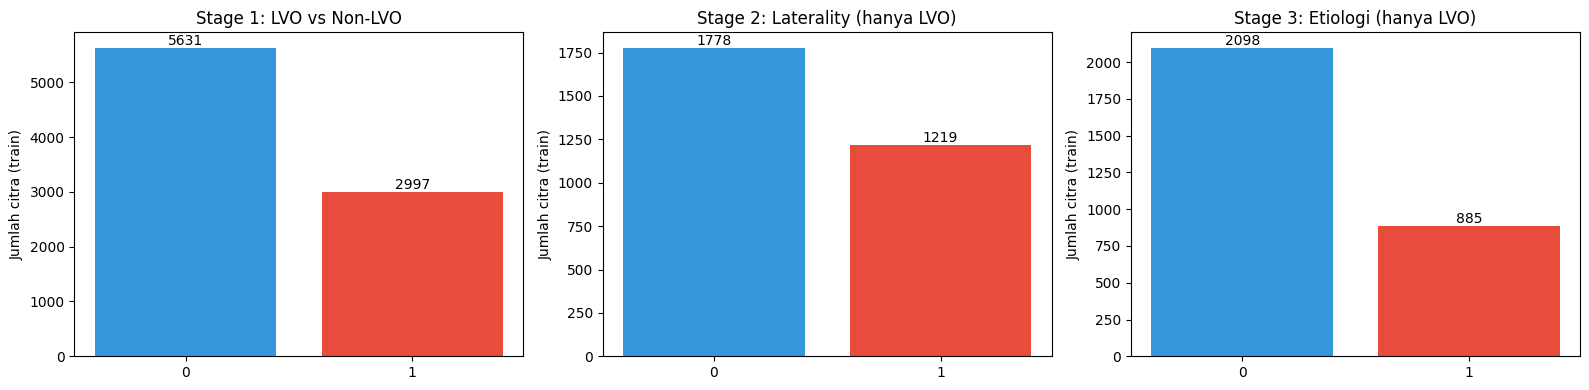

Slice/pasien (train stage1): mean=35.5  median=40  max=56


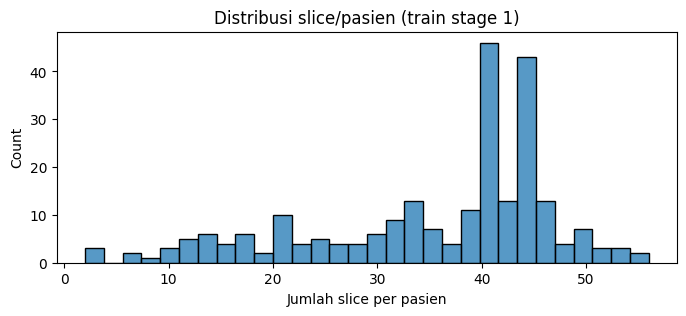

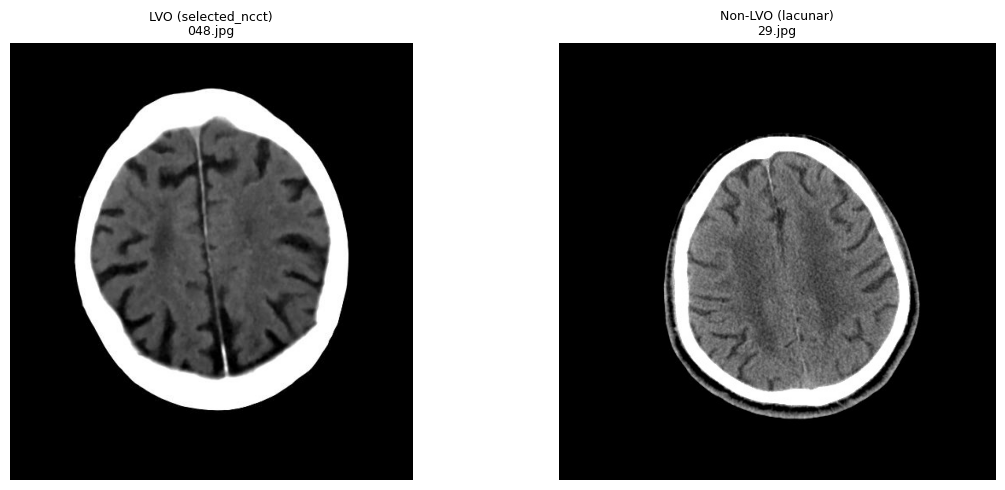

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
stage_titles = {'stage1_lvo': 'Stage 1: LVO vs Non-LVO',
                'stage2_laterality': 'Stage 2: Laterality (hanya LVO)',
                'stage3_etiology': 'Stage 3: Etiologi (hanya LVO)'}
for ax, stage in zip(axes, STAGES):
    vc = splits[(stage, 'train')]['label'].value_counts().sort_index()
    labels = {0: '0', 1: '1'}[vc.index[0]] if len(vc) else '0'
    ax.bar(vc.index.astype(str), vc.values, color=['#3498db', '#e74c3c'])
    ax.set_title(stage_titles[stage])
    for i, v in enumerate(vc.values):
        ax.annotate(str(int(v)), (i, v), ha='center', va='bottom')
    ax.set_ylabel('Jumlah citra (train)')
plt.tight_layout(); plt.show()

# Slice per pasien → evaluasi level pasien lebih bermakna
tr1 = splits[('stage1_lvo', 'train')]
spp = tr1.groupby('subject').size()
print(f'Slice/pasien (train stage1): mean={spp.mean():.1f}  median={spp.median():.0f}  max={spp.max()}')
plt.figure(figsize=(8, 3))
sns.histplot(spp, bins=30)
plt.xlabel('Jumlah slice per pasien')
plt.title('Distribusi slice/pasien (train stage 1)')
plt.show()

# Contoh citra tiap kelas
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for i, (title, lab) in enumerate([('LVO (selected_ncct)', 1), ('Non-LVO (lacunar)', 0)]):
    sub = tr1[tr1['label'] == lab]
    p = sub.sample(1, random_state=42 + i)['image_path'].iloc[0]
    img = Image.open(p).convert('RGB')
    axes[i].imshow(img)
    axes[i].set_title(f'{title}\n{os.path.basename(p)}', fontsize=9)
    axes[i].axis('off')
plt.tight_layout(); plt.show()

### 6. Dataset & Dataloader — dari Fixed Split

Berbeda dari V1, **tidak ada fungsi split di sini**. Loader dibuat langsung dari CSV fixed split.

Setiap sample mengembalikan `(image, label, subject, image_path)` — `subject` diperlukan untuk evaluasi level pasien (C1).

In [27]:
class StrokeImageDataset(Dataset):
    """Dataset citra stroke dari CSV fixed split: 1 sample = 1 citra + label + subject."""
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['image_path']).convert('RGB')
        if self.transform is not None:
            img = self.transform(img)
        return img, int(row['label']), row['subject'], row['image_path']


# Augmentasi ringan (sama dgn V1; bisa diperkuat utk eksperimen lanjutan)
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


def make_loaders(stage, batch_size=BATCH_SIZE):
    """Loader utk satu stage dari FIXED SPLIT (tidak ada split ulang)."""
    tr_ds = StrokeImageDataset(splits[(stage, 'train')], train_tf)
    va_ds = StrokeImageDataset(splits[(stage, 'val')], eval_tf)
    te_ds = StrokeImageDataset(splits[(stage, 'test')], eval_tf)
    tr_ld = DataLoader(tr_ds, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
    va_ld = DataLoader(va_ds, batch_size=batch_size, shuffle=False, num_workers=2)
    te_ld = DataLoader(te_ds, batch_size=batch_size, shuffle=False, num_workers=2)
    return tr_ld, va_ld, te_ld

### 7. Model & Fungsi Training — Config Proper

Peningkatan training dibanding V1:
- **Backbone ablation** — `build_model()` dipakai utk 4 arsitektur (A1).
- **Linear warmup** (1 epoch) → **CosineAnnealingLR**.
- **AMP** (mixed precision) via `torch.amp` → lebih cepat & hemat VRAM.
- **Gradient clipping** (max norm 1.0) + **weight decay**.
- **Multi-seed** (set_seed per run) utk ablation mean±std.
- **Evaluasi level pasien** (C1): agregasi probabilitas per subject → 1 prediksi pasien.

In [28]:
def build_model(num_classes=2, backbone='resnet18', pretrained=PRETRAINED):
    """Model CNN pretrained dari timm (utk ablation backbone)."""
    try:
        model = timm.create_model(backbone, pretrained=pretrained, num_classes=num_classes)
    except TypeError:
        weights = 'IMAGENET1K_V1' if pretrained else None
        model = timm.create_model(backbone, weights=weights, num_classes=num_classes)
    return model


def compute_metrics(y_true, y_pred, y_prob):
    return {
        'accuracy':  accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall':    recall_score(y_true, y_pred, zero_division=0),
        'f1':        f1_score(y_true, y_pred, zero_division=0),
        'auc':       roc_auc_score(y_true, y_prob) if len(set(y_true)) > 1 else float('nan'),
    }


@torch.no_grad()
def evaluate_model(model, loader, criterion=None):
    """Evaluasi pada loader. Return (metrics, records) dengan records per-citra:
    [(subject, y_true, y_pred, y_prob), ...] → dipakai utk level pasien."""
    model.eval()
    records, loss_sum, n = [], 0.0, 0
    for xb, yb, subj, _ in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        probs  = torch.softmax(logits, dim=1)
        records += [(s, int(yt), int(yp), float(pr)) for s, yt, yp, pr in
                    zip(subj, yb.tolist(), probs.argmax(1).tolist(), probs[:, 1].tolist())]
        if criterion is not None:
            loss_sum += criterion(logits, yb).item() * len(yb)
            n += len(yb)
    y_true = [r[1] for r in records]
    y_pred = [r[2] for r in records]
    y_prob = [r[3] for r in records]
    metrics = compute_metrics(y_true, y_pred, y_prob)
    if criterion is not None:
        metrics['loss'] = loss_sum / max(n, 1)
    return metrics, records


def patient_level_metrics(records):
    """Agregasi per-PASIEN: rata-rata prob per slice → 1 prediksi pasien (threshold 0.5)."""
    pdf = pd.DataFrame(records, columns=['subject', 'y_true', 'y_pred', 'y_prob'])
    agg = (pdf.groupby('subject')
              .agg(y_true=('y_true', 'first'), p=('y_prob', 'mean'))
              .reset_index())
    agg['y_pred'] = (agg['p'] >= 0.5).astype(int)
    return compute_metrics(agg['y_true'].tolist(), agg['y_pred'].tolist(), agg['p'].tolist()), agg


def train_model(model, train_loader, val_loader, epochs=EPOCHS, lr=LR, patience=PATIENCE,
                label='', class_weights=None, seed=42, amp=AMP):
    """Training proper: warmup + cosine, AMP, grad clip, early stopping, seed fix."""
    set_seed(seed)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)

    if WARMUP_EPOCHS > 0 and WARMUP_EPOCHS < epochs:
        warmup = optim.lr_scheduler.LinearLR(optimizer, start_factor=0.1, total_iters=WARMUP_EPOCHS)
        cosine = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs - WARMUP_EPOCHS)
        scheduler = optim.lr_scheduler.SequentialLR(optimizer, [warmup, cosine],
                                                    milestones=[WARMUP_EPOCHS])
    else:
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    use_amp = amp and device.type == 'cuda'
    scaler = torch.amp.GradScaler('cuda', enabled=use_amp)
    history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}
    best_f1, best_epoch, bad_epochs = -1.0, 0, 0
    save_path = os.path.join(OUTPUT_DIR, f'{label}_best.pt')

    for epoch in range(1, epochs + 1):
        model.train()
        tot_loss, tot = 0.0, 0
        for xb, yb, _, _ in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            with torch.amp.autocast('cuda', enabled=use_amp):
                logits = model(xb)
                loss = criterion(logits, yb)
            scaler.scale(loss).backward()
            if GRAD_CLIP:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            scaler.step(optimizer)
            scaler.update()
            tot_loss += loss.item() * len(yb)
            tot += len(yb)
        scheduler.step()

        val_metrics, _ = evaluate_model(model, val_loader, criterion=criterion)
        tl = tot_loss / max(tot, 1)
        history['train_loss'].append(tl)
        history['val_loss'].append(val_metrics.get('loss', float('nan')))
        history['val_acc'].append(val_metrics['accuracy'])
        history['val_f1'].append(val_metrics['f1'])

        print(f'[{label}] epoch {epoch:02d}/{epochs} | train_loss={tl:.4f} '
              f'| val_loss={val_metrics.get("loss", float("nan")):.4f} '
              f'| val_acc={val_metrics["accuracy"]:.4f} | val_f1={val_metrics["f1"]:.4f}')

        if val_metrics['f1'] > best_f1:
            best_f1, best_epoch, bad_epochs = val_metrics['f1'], epoch, 0
            torch.save(model.state_dict(), save_path)
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                print(f'  >> Early stop di epoch {epoch} (best F1={best_f1:.4f} di epoch {best_epoch})')
                break

    if os.path.exists(save_path):
        model.load_state_dict(torch.load(save_path, map_location=device))
    print(f'[{label}] Selesai. Best val F1 = {best_f1:.4f} (epoch {best_epoch})')
    return model, history

### 8. Ablation Runner

Framework ablation — mengikuti pola `v8_ablation.py` dari proyek segmentation:
- Loop **stage × backbone × seed** dengan fixed split yang sama.
- Class weight per stage (mengatasi imbalance).
- Hasil tiap run: val F1, metrik **test level citra**, metrik **test level pasien**.
- Otomatis menyimpan: **JSON** (hasil mentah), **CSV** (ringkasan), **Markdown** (laporan tabel).

In [29]:
def class_weights_for(stage):
    tr = splits[(stage, 'train')]
    counts = np.bincount(tr['label'].values)
    cw = torch.tensor(len(tr) / (2 * counts), dtype=torch.float32).to(device)
    return cw, counts


def run_ablation(backbones=None, seeds=None, stages=None, epochs=None):
    """Ablation backbone × stage × seed pada fixed split.

    Return: results[stage][backbone][seed] = {'val_f1', 'test': dict, 'patient': dict|None, 'history': dict}
    """
    backbones = backbones or BACKBONES
    seeds     = seeds or SEEDS
    stages    = stages or STAGES
    epochs    = epochs or EPOCHS
    results, t0 = {}, time.time()

    for stage in stages:
        cw, counts = class_weights_for(stage)
        print(f'\n{"="*72}\nSTAGE {stage} | distribusi train: {dict(zip([0, 1], counts))}\n{"="*72}')
        tr_ld, va_ld, te_ld = make_loaders(stage)
        print(f'Citra train: {len(tr_ld.dataset)} | val: {len(va_ld.dataset)} | test: {len(te_ld.dataset)}')
        results[stage] = {}
        for bb in backbones:
            results[stage][bb] = {}
            for seed in seeds:
                set_seed(seed)
                model = build_model(2, bb).to(device)
                model, hist = train_model(model, tr_ld, va_ld, epochs=epochs,
                                          label=f'{stage}_{bb}', class_weights=cw, seed=seed)
                te_metrics, te_recs = evaluate_model(model, te_ld)
                pa_metrics = None
                if PATIENT_LEVEL:
                    pa_metrics, _ = patient_level_metrics(te_recs)
                results[stage][bb][seed] = {
                    'val_f1': max(hist['val_f1']),
                    'test': te_metrics,
                    'patient': pa_metrics,
                    'history': hist,
                }
                pa_txt = f' | patient f1={pa_metrics["f1"]:.4f}' if pa_metrics else ''
                print(f'  ✔ {bb} (seed={seed}) | test acc={te_metrics["accuracy"]:.4f} '
                      f'f1={te_metrics["f1"]:.4f}{pa_txt}')

    print(f'\n⏱ Total waktu: {(time.time() - t0) / 60:.1f} menit')
    return results


# ---------- Tabel & penyimpanan hasil ----------

def fmt_mean_std(values):
    vals = [v for v in values if v is not None and not (isinstance(v, float) and np.isnan(v))]
    if not vals:
        return 'N/A'
    return f'{np.mean(vals):.4f}±{np.std(vals):.4f}'


def ablation_table(results, level='test'):
    """Tabel markdown per stage: backbone × metrik (mean±std antar seed)."""
    metrics = ['accuracy', 'precision', 'recall', 'f1', 'auc']
    lines = []
    for stage in results:
        lines.append(f'\n### {stage} — level **{level}**')
        lines.append('| Backbone | ' + ' | '.join(m.capitalize() for m in metrics) + ' |')
        lines.append('|---|' + '---|' * len(metrics))
        for bb in results[stage]:
            cells = []
            for m in metrics:
                vals = [r[level][m] for r in results[stage][bb].values()
                        if r[level] is not None and m in r[level]]
                cells.append(fmt_mean_std(vals))
            lines.append(f'| {bb} | ' + ' | '.join(cells) + ' |')
    return '\n'.join(lines)


def save_ablation_results(results, tag=''):
    """Simpan hasil ablation ke JSON + CSV + Markdown di OUTPUT_DIR."""
    ts = time.strftime('%Y%m%d_%H%M%S')
    # JSON (tanpa history agar ringkas)
    slim = {stage: {bb: {str(sd): {k: v for k, v in r.items() if k != 'history'}
                         for sd, r in sdct.items()}
                    for bb, sdct in stct.items()}
            for stage, stct in results.items()}
    json_path = os.path.join(OUTPUT_DIR, f'ablation_results{tag}_{ts}.json')
    with open(json_path, 'w') as f:
        json.dump(slim, f, indent=2, default=str)

    # CSV ringkasan
    rows = []
    for stage in results:
        for bb in results[stage]:
            for level in ['test', 'patient']:
                first = next(iter(results[stage][bb].values()))
                if first[level] is None:
                    continue
                row = {'stage': stage, 'backbone': bb, 'level': level}
                for m in ['accuracy', 'precision', 'recall', 'f1', 'auc']:
                    vals = [r[level][m] for r in results[stage][bb].values()
                            if r[level] is not None and m in r[level]]
                    row[m] = fmt_mean_std(vals)
                rows.append(row)
    csv_path = os.path.join(OUTPUT_DIR, f'ablation_summary{tag}_{ts}.csv')
    pd.DataFrame(rows).to_csv(csv_path, index=False)

    # Laporan Markdown
    md_path = os.path.join(OUTPUT_DIR, f'ablation_report{tag}_{ts}.md')
    with open(md_path, 'w') as f:
        f.write('# NCCT Multi-Stage V2 — Ablation Backbone\n\n')
        f.write(ablation_table(results, 'test'))
        if PATIENT_LEVEL:
            f.write('\n\n' + ablation_table(results, 'patient'))
    print('Tersimpan:')
    print('  ', json_path)
    print('  ', csv_path)
    print('  ', md_path)


def plot_ablation_bars(results, level='test', metric='f1'):
    """Bar chart per stage utk satu metrik (mean ± std antar seed)."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
    for ax, stage in zip(axes, STAGES):
        if stage not in results:
            continue
        names, means, stds = [], [], []
        for bb in results[stage]:
            vals = [r[level][metric] for r in results[stage][bb].values()
                    if r[level] is not None and metric in r[level]]
            names.append(bb)
            means.append(np.mean(vals))
            stds.append(np.std(vals))
        bars = ax.bar(names, means, yerr=stds, capsize=4, color='#3498db')
        for b, v in zip(bars, means):
            ax.annotate(f'{v:.3f}', (b.get_x() + b.get_width() / 2, v),
                        ha='center', va='bottom', fontsize=8)
        ax.set_title(f'{stage}\n{metric.upper()} ({level})')
        ax.set_ylim(0, 1.05)
        ax.tick_params(axis='x', rotation=30)
    plt.tight_layout(); plt.show()

### 9. Menjalankan Ablation

> **Estimasi waktu (Colab GPU):** 1 run ≈ 10–30 menit tergantung backbone & jumlah citra.
> Total = jumlah stage × backbone × seed. Untuk uji cepat, batasi variabel `RUN_*` di bawah.

In [30]:
# ============================================================
#  KONFIGURASI RUN 
# ============================================================
RUN_STAGES    = STAGES            # mis. ['stage1_lvo'] utk coba 1 stage dulu
RUN_BACKBONES = BACKBONES         # mis. ['resnet18', 'convnext_tiny']
RUN_SEEDS     = SEEDS             # mis. [42]
RUN_EPOCHS    = EPOCHS            

results = run_ablation(backbones=RUN_BACKBONES, seeds=RUN_SEEDS,
                       stages=RUN_STAGES, epochs=RUN_EPOCHS)


STAGE stage1_lvo | distribusi train: {0: np.int64(5631), 1: np.int64(2997)}
Citra train: 8628 | val: 1851 | test: 1759
[stage1_lvo_resnet18] epoch 01/1 | train_loss=0.1985 | val_loss=0.0562 | val_acc=0.9865 | val_f1=0.9744
[stage1_lvo_resnet18] Selesai. Best val F1 = 0.9744 (epoch 1)
  ✔ resnet18 (seed=42) | test acc=0.9909 f1=0.9805 | patient f1=1.0000
[stage1_lvo_resnet50] epoch 01/1 | train_loss=0.2230 | val_loss=0.0407 | val_acc=0.9849 | val_f1=0.9714
[stage1_lvo_resnet50] Selesai. Best val F1 = 0.9714 (epoch 1)
  ✔ resnet50 (seed=42) | test acc=0.9909 f1=0.9805 | patient f1=1.0000
[stage1_lvo_efficientnet_b0] epoch 01/1 | train_loss=0.2271 | val_loss=0.0979 | val_acc=0.9784 | val_f1=0.9587
[stage1_lvo_efficientnet_b0] Selesai. Best val F1 = 0.9587 (epoch 1)
  ✔ efficientnet_b0 (seed=42) | test acc=0.9699 f1=0.9325 | patient f1=0.9189


model.safetensors: reconstructing file:   0%|          |  0.00B /  114MB            

model.safetensors: downloading bytes:           |  0.00B            

[stage1_lvo_convnext_tiny] epoch 01/1 | train_loss=0.1945 | val_loss=0.2350 | val_acc=0.9233 | val_f1=0.8743
[stage1_lvo_convnext_tiny] Selesai. Best val F1 = 0.8743 (epoch 1)
  ✔ convnext_tiny (seed=42) | test acc=0.9477 f1=0.9009 | patient f1=0.9756

STAGE stage2_laterality | distribusi train: {0: np.int64(1778), 1: np.int64(1219)}
Citra train: 2997 | val: 497 | test: 418
[stage2_laterality_resnet18] epoch 01/1 | train_loss=0.6749 | val_loss=0.7073 | val_acc=0.4105 | val_f1=0.5327
[stage2_laterality_resnet18] Selesai. Best val F1 = 0.5327 (epoch 1)
  ✔ resnet18 (seed=42) | test acc=0.5885 f1=0.5924 | patient f1=0.6087
[stage2_laterality_resnet50] epoch 01/1 | train_loss=0.6870 | val_loss=0.6991 | val_acc=0.4165 | val_f1=0.5215
[stage2_laterality_resnet50] Selesai. Best val F1 = 0.5215 (epoch 1)
  ✔ resnet50 (seed=42) | test acc=0.5622 f1=0.6164 | patient f1=0.6154
[stage2_laterality_efficientnet_b0] epoch 01/1 | train_loss=1.3773 | val_loss=2.0111 | val_acc=0.5010 | val_f1=0.5679
[st

### 10. Hasil Ablation — Tabel & Plot

Tabel otomatis: **level citra** (test) dan **level pasien** (jika `PATIENT_LEVEL=True`).


### stage1_lvo — level **test**
| Backbone | Accuracy | Precision | Recall | F1 | Auc |
|---|---|---|---|---|---|
| resnet18 | 0.9909±0.0000 | 0.9975±0.0000 | 0.9641±0.0000 | 0.9805±0.0000 | 0.9975±0.0000 |
| resnet50 | 0.9909±0.0000 | 0.9975±0.0000 | 0.9641±0.0000 | 0.9805±0.0000 | 0.9982±0.0000 |
| efficientnet_b0 | 0.9699±0.0000 | 0.9973±0.0000 | 0.8756±0.0000 | 0.9325±0.0000 | 0.9985±0.0000 |
| convnext_tiny | 0.9477±0.0000 | 0.8196±0.0000 | 1.0000±0.0000 | 0.9009±0.0000 | 0.9994±0.0000 |

### stage2_laterality — level **test**
| Backbone | Accuracy | Precision | Recall | F1 | Auc |
|---|---|---|---|---|---|
| resnet18 | 0.5885±0.0000 | 0.5365±0.0000 | 0.6614±0.0000 | 0.5924±0.0000 | 0.5886±0.0000 |
| resnet50 | 0.5622±0.0000 | 0.5104±0.0000 | 0.7778±0.0000 | 0.6164±0.0000 | 0.5987±0.0000 |
| efficientnet_b0 | 0.4833±0.0000 | 0.4421±0.0000 | 0.5450±0.0000 | 0.4882±0.0000 | 0.4607±0.0000 |
| convnext_tiny | 0.5000±0.0000 | 0.4697±0.0000 | 0.8201±0.0000 | 0.5973±0.0000 | 0.6129±0.00

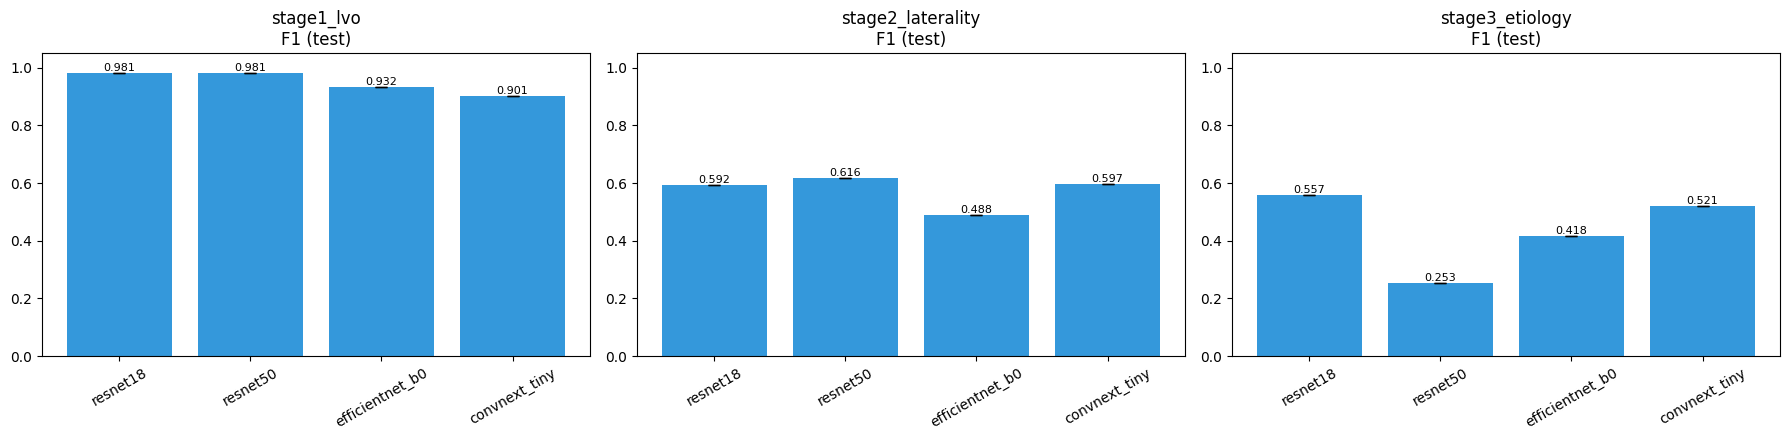

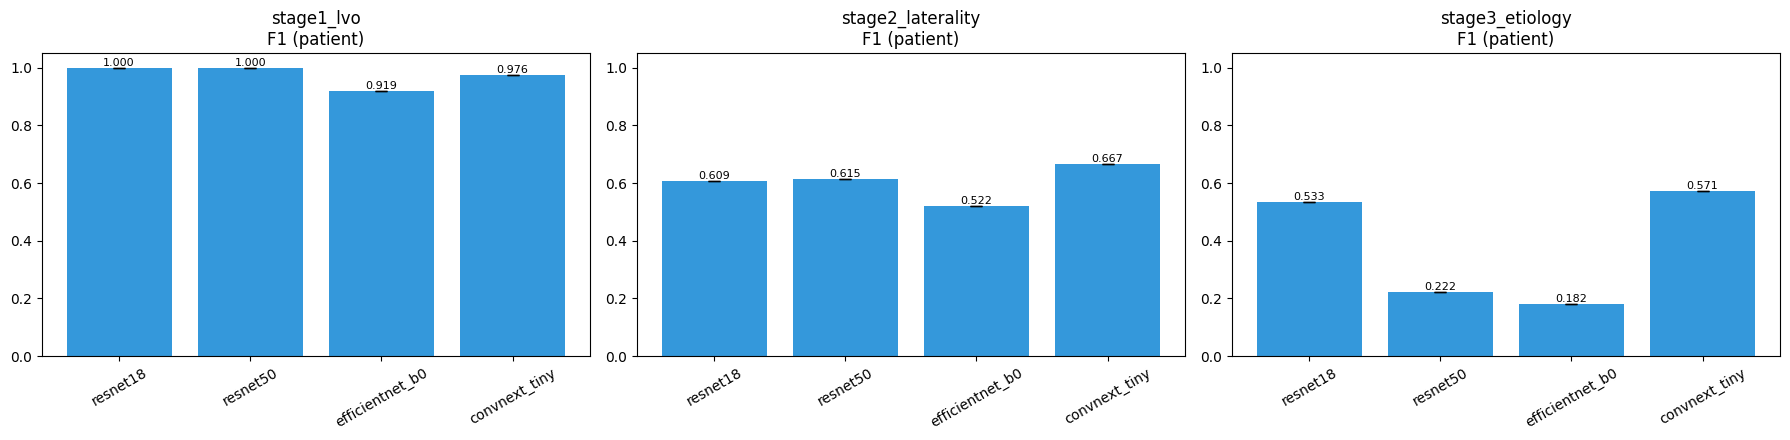

In [31]:
print(ablation_table(results, 'test'))
if PATIENT_LEVEL:
    print(ablation_table(results, 'patient'))

# Simpan ke file
save_ablation_results(results)

# Plot F1
plot_ablation_bars(results, 'test', 'f1')
if PATIENT_LEVEL:
    plot_ablation_bars(results, 'patient', 'f1')

### 11. Evaluasi Level Pasien

Karena ~35 slice/pasien, metrik per-citra terlalu optimis (slice sepasien sangat mirip).
Di sini metrik dihitung **per pasien**: probabilitas seluruh slice dirata-rata → 1 prediksi per pasien.

> Bandingkan F1 level citra vs level pasien — selisihnya menunjukkan seberapa "mudah" masalah di level citra.

In [32]:
print('===== EVALUASI LEVEL PASIEN (test) — per backbone =====')
for stage in results:
    print(f'\n--- {stage} ---')
    print(f"{'Backbone':<18}{'Acc':>8}{'Prec':>8}{'Rec':>8}{'F1':>8}{'AUC':>8}")
    for bb in results[stage]:
        pa = results[stage][bb][RUN_SEEDS[0]]['patient']
        if pa is None:
            continue
        print(f"{bb:<18}{pa['accuracy']:>8.4f}{pa['precision']:>8.4f}"
              f"{pa['recall']:>8.4f}{pa['f1']:>8.4f}{pa['auc']:>8.4f}")

# Perbandingan ringkas citra vs pasien (F1, backbone terbaik per stage)
print('\n===== F1: level citra vs level pasien (backbone terbaik per stage) =====')
for stage in results:
    best_bb = max(results[stage],
                  key=lambda bb: np.mean([r['test']['f1'] for r in results[stage][bb].values()]))
    r = results[stage][best_bb][RUN_SEEDS[0]]
    img_f1 = r['test']['f1']
    pat_f1 = r['patient']['f1'] if r['patient'] else float('nan')
    print(f'  {stage:22s} {best_bb:<16s} citra F1={img_f1:.4f} | pasien F1={pat_f1:.4f}')

===== EVALUASI LEVEL PASIEN (test) — per backbone =====

--- stage1_lvo ---
Backbone               Acc    Prec     Rec      F1     AUC
resnet18            1.0000  1.0000  1.0000  1.0000  1.0000
resnet50            1.0000  1.0000  1.0000  1.0000  1.0000
efficientnet_b0     0.9423  1.0000  0.8500  0.9189  1.0000
convnext_tiny       0.9808  0.9524  1.0000  0.9756  1.0000

--- stage2_laterality ---
Backbone               Acc    Prec     Rec      F1     AUC
resnet18            0.5500  0.5000  0.7778  0.6087  0.6364
resnet50            0.5000  0.4706  0.8889  0.6154  0.6162
efficientnet_b0     0.4500  0.4286  0.6667  0.5217  0.4343
convnext_tiny       0.5500  0.5000  1.0000  0.6667  0.6162

--- stage3_etiology ---
Backbone               Acc    Prec     Rec      F1     AUC
resnet18            0.6500  0.4444  0.6667  0.5333  0.7143
resnet50            0.6500  0.3333  0.1667  0.2222  0.5952
efficientnet_b0     0.5500  0.2000  0.1667  0.1818  0.5595
convnext_tiny       0.7000  0.5000  0.6667  0.

### 12. Pipeline Multi-Stage End-to-End (Level Pasien)

Pipeline klinis: 1 pasien (banyak slice) → **Stage 1** (LVO/Non-LVO) → jika LVO lanjut **Stage 2** (laterality) & **Stage 3** (etiologi).

Keputusan per pasien = rata-rata probabilitas seluruh slice-nya (bukan per citra).

In [33]:
def best_backbone(results, level='test', metric='f1'):
    """Pilih backbone terbaik per stage (mean metrik antar seed)."""
    best = {}
    for stage in results:
        scores = {}
        for bb in results[stage]:
            vals = [r[level][metric] for r in results[stage][bb].values()
                    if r[level] is not None]
            scores[bb] = np.mean(vals) if vals else -1.0
        best[stage] = max(scores, key=scores.get)
    return best


best_bb = best_backbone(results)
print('Backbone terbaik per stage (test F1):')
for stage, bb in best_bb.items():
    print(f'  {stage:22s} → {bb}')


def load_best_model(stage, backbone):
    m = build_model(2, backbone).to(device)
    m.load_state_dict(torch.load(os.path.join(OUTPUT_DIR, f'{stage}_{backbone}_best.pt'),
                                 map_location=device))
    m.eval()
    return m


models = {stage: load_best_model(stage, best_bb[stage]) for stage in results}
print('\nModel terbaik dimuat:', {k: v for k, v in best_bb.items()})


def patient_prob(df, model):
    """Rata-rata probabilitas (kelas 1) seluruh slice satu pasien."""
    ds = StrokeImageDataset(df, eval_tf)
    ld = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    probs = []
    model.eval()
    with torch.no_grad():
        for xb, _, _, _ in ld:
            xb = xb.to(device)
            probs.extend(torch.softmax(model(xb), dim=1)[:, 1].tolist())
    return float(np.mean(probs))


def predict_patient(subject, models, stage_df=splits):
    """Pipeline utk SATU pasien: stage1 → jika LVO lanjut stage2 & 3."""
    res = {'subject': subject}

    # ---- Stage 1 ----
    df1 = stage_df[('stage1_lvo', 'test')]
    rows1 = df1[df1['subject'] == subject]
    p1 = patient_prob(rows1, models['stage1_lvo'])
    res['p_lvo'] = p1
    res['pred_stage1'] = 'LVO' if p1 >= 0.5 else 'Non-LVO'

    if res['pred_stage1'] == 'LVO':
        # ---- Stage 2: Laterality ----
        df2 = stage_df[('stage2_laterality', 'test')]
        rows2 = df2[df2['subject'] == subject]
        if len(rows2) > 0:
            p2 = patient_prob(rows2, models['stage2_laterality'])
            res['pred_laterality'] = 'Left' if p2 < 0.5 else 'Right'
            res['p_right'] = p2
        else:
            res['pred_laterality'] = None

        # ---- Stage 3: Etiologi ----
        df3 = stage_df[('stage3_etiology', 'test')]
        rows3 = df3[df3['subject'] == subject]
        if len(rows3) > 0:
            p3 = patient_prob(rows3, models['stage3_etiology'])
            res['pred_etiology'] = 'Cardioembolic' if p3 >= 0.5 else 'Non-Cardioembolic'
            res['p_cardio'] = p3
        else:
            res['pred_etiology'] = None
    else:
        res['pred_laterality'] = None
        res['pred_etiology'] = None
    return res

Backbone terbaik per stage (test F1):
  stage1_lvo             → resnet18
  stage2_laterality      → resnet50
  stage3_etiology        → resnet18

Model terbaik dimuat: {'stage1_lvo': 'resnet18', 'stage2_laterality': 'resnet50', 'stage3_etiology': 'resnet18'}


In [34]:
# ===== Evaluasi pipeline end-to-end pada SEMUA pasien test (level pasien) =====
test_subj = splits[('stage1_lvo', 'test')]['subject'].unique()
pipe_rows = []
for s in test_subj:
    pipe_rows.append(predict_patient(s, models))
pipe = pd.DataFrame(pipe_rows)

# GT per pasien (dari fixed split)
gt1 = splits[('stage1_lvo', 'test')].drop_duplicates('subject').set_index('subject')['label']
gt2 = splits[('stage2_laterality', 'test')].drop_duplicates('subject').set_index('subject')['label']
gt3 = splits[('stage3_etiology', 'test')].drop_duplicates('subject').set_index('subject')['label']

pipe['gt_lvo'] = pipe['subject'].map(gt1)
pipe['gt_lat'] = pipe['subject'].map(gt2)
pipe['gt_etio'] = pipe['subject'].map(gt3)
acc1 = (pipe['gt_lvo'] == (pipe['pred_stage1'] == 'LVO').astype(int)).mean()
print(f'Stage 1 acc (level pasien, n={len(pipe)}): {acc1:.4f}')

sub2 = pipe.dropna(subset=['pred_laterality', 'gt_lat'])
if len(sub2) > 0:
    acc2 = (sub2['gt_lat'] == (sub2['pred_laterality'] == 'Right').astype(int)).mean()
    print(f'Stage 2 acc (pasien LVO, n={len(sub2)}): {acc2:.4f}')

sub3 = pipe.dropna(subset=['pred_etiology', 'gt_etio'])
if len(sub3) > 0:
    acc3 = (sub3['gt_etio'] == (sub3['pred_etiology'] == 'Cardioembolic').astype(int)).mean()
    print(f'Stage 3 acc (pasien LVO, n={len(sub3)}): {acc3:.4f}')

display(pipe.head(10))

Stage 1 acc (level pasien, n=52): 1.0000
Stage 2 acc (pasien LVO, n=20): 0.5000
Stage 3 acc (pasien LVO, n=20): 0.6500


,subject,p_lvo,pred_stage1,pred_laterality,p_right,pred_etiology,p_cardio,gt_lvo,gt_lat,gt_etio
0,sub-stroke0139,0.982843,LVO,Right,0.516584,Non-Cardioembolic,0.493852,1,0.0,1.0
1,sub-stroke0148,0.783195,LVO,Right,0.524101,Cardioembolic,0.510105,1,1.0,0.0
2,sub-stroke0010,0.990468,LVO,Right,0.507615,Cardioembolic,0.572289,1,1.0,1.0
3,sub-stroke0153,0.618652,LVO,Right,0.508929,Cardioembolic,0.550381,1,1.0,1.0
4,sub-stroke0164,0.849331,LVO,Right,0.519825,Non-Cardioembolic,0.488047,1,1.0,0.0
5,sub-stroke0165,0.951507,LVO,Right,0.520494,Non-Cardioembolic,0.364852,1,0.0,0.0
6,sub-stroke0168,0.988868,LVO,Right,0.515378,Non-Cardioembolic,0.435843,1,0.0,0.0
7,sub-stroke0178,0.910053,LVO,Right,0.503600,Non-Cardioembolic,0.475058,1,0.0,0.0
8,sub-stroke0179,0.970742,LVO,Right,0.538447,Non-Cardioembolic,0.366688,1,0.0,0.0
9,sub-stroke0027,0.968016,LVO,Right,0.508990,Non-Cardioembolic,0.378229,1,0.0,0.0


### 13. Visualisasi Prediksi Pipeline

Contoh prediksi end-to-end per pasien pada test set (hijau = benar, merah = salah).

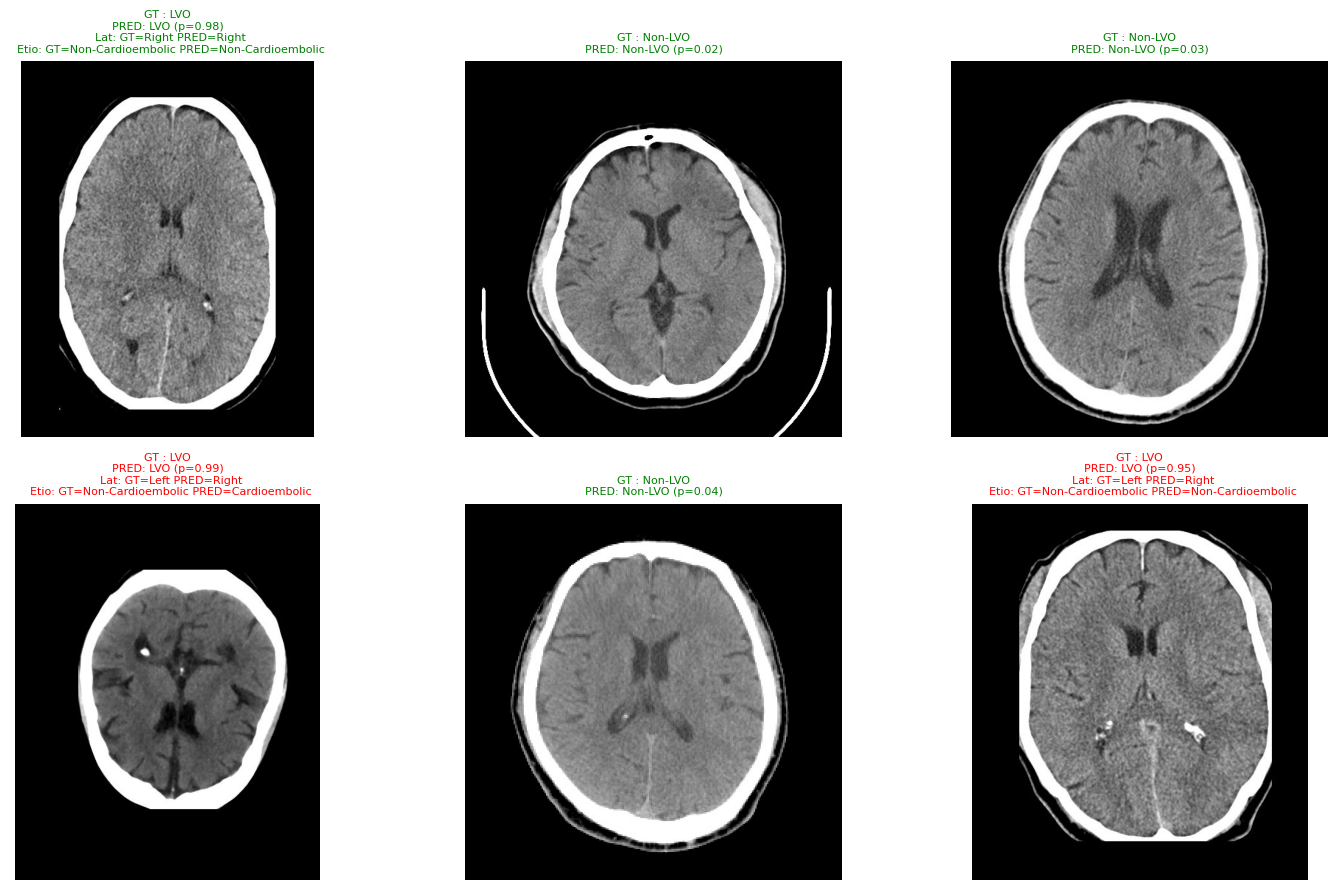

In [35]:
def plot_patient_predictions(pipe, n=6):
    sample = pipe.sample(min(n, len(pipe)), random_state=42)
    cols = min(3, len(sample))
    rows = int(np.ceil(len(sample) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4.5 * rows))
    axes = np.atleast_1d(axes).ravel()
    for ax, (_, r) in zip(axes, sample.iterrows()):
        # citra tengah pasien (representatif)
        df1 = splits[('stage1_lvo', 'test')]
        rows_p = df1[df1['subject'] == r['subject']]
        mid = rows_p.iloc[len(rows_p) // 2]['image_path']
        img = Image.open(mid).convert('RGB')
        ax.imshow(img); ax.axis('off')

        ok1 = r['gt_lvo'] == int(r['pred_stage1'] == 'LVO')
        t = f"GT : {'LVO' if r['gt_lvo'] == 1 else 'Non-LVO'}\nPRED: {r['pred_stage1']} (p={r['p_lvo']:.2f})"
        color = 'green' if ok1 else 'red'
        if r['pred_laterality'] is not None and pd.notna(r['gt_lat']):
            gt2m = 'Right' if r['gt_lat'] == 1 else 'Left'
            ok2 = r['pred_laterality'] == gt2m
            t += f"\n  Lat: GT={gt2m} PRED={r['pred_laterality']}"
            color = 'green' if ok1 and ok2 else 'red'
        if r['pred_etiology'] is not None and pd.notna(r['gt_etio']):
            gt3m = 'Cardioembolic' if r['gt_etio'] == 1 else 'Non-Cardioembolic'
            ok3 = r['pred_etiology'] == gt3m
            t += f"\n  Etio: GT={gt3m} PRED={r['pred_etiology']}"
            color = 'green' if ok1 and ok2 and ok3 else 'red'
        ax.set_title(t, fontsize=8, color=color)
    for ax in axes[len(sample):]:
        ax.axis('off')
    plt.tight_layout(); plt.show()


plot_patient_predictions(pipe)

### 14. Kurva Training

Kurva loss & F1 validasi per backbone pada tiap stage (seed pertama).

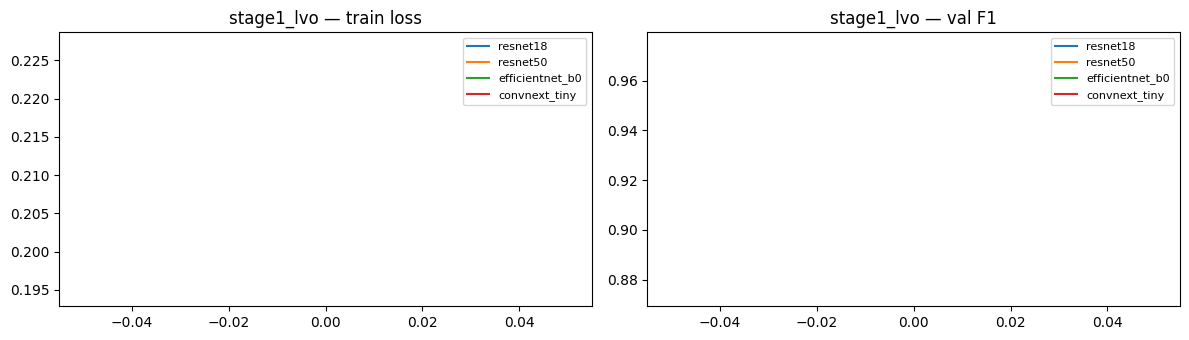

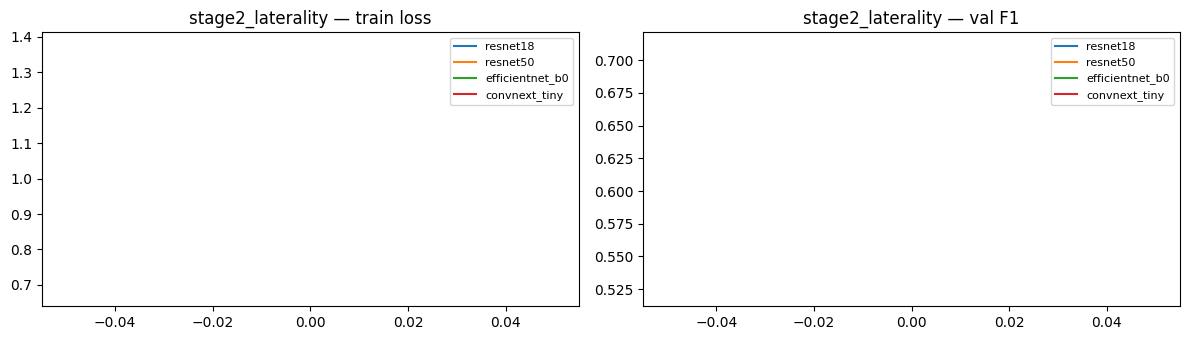

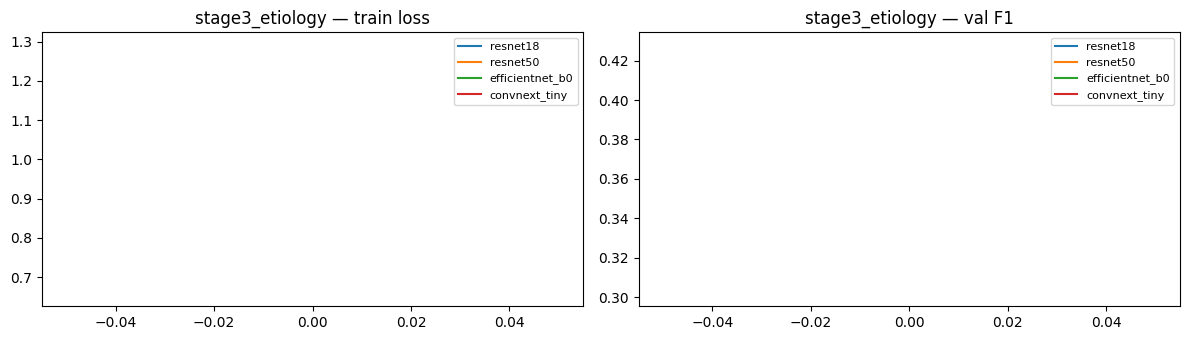

In [36]:
def plot_training_curves(results):
    for stage in results:
        fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
        for bb in results[stage]:
            hist = results[stage][bb][RUN_SEEDS[0]]['history']
            ax[0].plot(hist['train_loss'], label=bb)
            ax[1].plot(hist['val_f1'], label=bb)
        ax[0].set_title(f'{stage} — train loss'); ax[0].legend(fontsize=8)
        ax[1].set_title(f'{stage} — val F1'); ax[1].legend(fontsize=8)
        plt.tight_layout(); plt.show()


plot_training_curves(results)

### 15. Ringkasan & Kesimpulan

**V2 selesai — perbedaan utama dari V1:**

| Fitur | V1 | V2 |
|-------|----|----|
| Split | on-the-fly per stage | **Fixed split** (reproducible, konsisten antar stage) |
| Backbone | resnet18 saja | **Ablation**: resnet18 / resnet50 / efficientnet_b0 / convnext_tiny |
| Training | 1 epoch, CE, AdamW+Cosine | Warmup+cosine, **AMP**, grad clip, weight decay, multi-seed |
| Evaluasi | level citra | **Level citra + level pasien** (mean prob) |
| Output | model per stage | Model per stage + tabel ablation (JSON/CSV/MD) + plot |

**Cara membaca hasil ablation:**
- Bandingkan kolom **F1** pada tabel level citra (test) dan level pasien.
- Backbone terbaik per stage dipakai otomatis di pipeline multi-stage (sel 12).
- Untuk hasil lebih stabil, jalankan dengan `SEEDS = [42, 43, 44]` → tabel menampilkan mean±std.

**Catatan:**
- Pipeline end-to-end mengevaluasi **level pasien** — lebih relevan klinis daripada level citra.
- Untuk sample lokal hasil hanyalah uji kode; jalankan dengan **dataset penuh di Colab** (mode `'colab'`) utk hasil valid.
- File hasil ablation tersimpan di folder `outputs/` (`ablation_results_*.json`, `ablation_summary_*.csv`, `ablation_report_*.md`).